In [1]:
import os, time, cv2, gc
import copy
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def elapsed(): return time.strftime("%H:%M:%S")

In [2]:
path_data = r'/home/d.golomolzin/AI_labs/2lab/my_dataset/'
X_train_path = os.path.join(path_data, 'train')
y_train_path = os.path.join(path_data, 'train_labels')
X_valid_path = os.path.join(path_data, 'valid')
y_valid_path = os.path.join(path_data, 'valid_labels')


class DataSet:
    '''Датасет дорог по переданным путям папок'''
    
    def __init__(self, X_path: str, y_path: str, is_test: bool = False):
        self.X_pathes, self.y_pathes = self.unpack(X_path, y_path)
        self.is_test = is_test

        self.transform1 = A.Compose([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Rotate(limit=15, p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]), # type: ignore
            ToTensorV2()
        ])
        self.transform2 = A.Compose([
            A.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]), # type: ignore
            ToTensorV2()
        ])

    def unpack(self, X_path: str, y_path: str):
        '''Вытаскивает пути к изображениям'''
        X, y = [], []
        for img_path, lbl_path in zip(sorted(os.listdir(X_path)), sorted(os.listdir(y_path))):
            X.append(os.path.join(X_path, img_path))
            y.append(os.path.join(y_path, lbl_path))
        return X, y
    
    def __getitem__(self, key):

        image = np.array(Image.open(self.X_pathes[key]).convert('RGB'))
        label = np.array(Image.open(self.y_pathes[key]).convert('L'))

        aug = (self.transform2 if self.is_test else self.transform1)(image=image, mask=label)

        image_t = aug['image']
        label_t = aug['mask']

        return image_t, (label_t > 0.5).long()

    def __len__(self):
        return len(self.y_pathes)

In [3]:
batch_size = 32

trainloader = DataLoader(
    DataSet(X_train_path, y_train_path),
    batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=False)
validloader = DataLoader(
    DataSet(X_valid_path, y_valid_path),
    batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=False)
it = iter(trainloader)

In [4]:
device = torch.device('cuda')
model = smp.Unet(encoder_name='resnet50', encoder_weights='imagenet')

model = nn.DataParallel(model).to(device)
best_model = None

optimizer = torch.optim.AdamW(params=model.parameters(), lr=3e-4, weight_decay=1e-5)

dice_func = smp.losses.DiceLoss(mode='binary')
bce_func = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([3.0]).to(device))

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

Обучение

In [ ]:
train_samples = len(trainloader.dataset)
valid_samples = len(validloader.dataset)
iouses, dices, bceses, accses = [], [], [], []
train_losses, valid_losses = [], []

EPOCH = 20

green = "\033[92m"
reset = "\033[0m"

koef = 0.9
model.train()
best_iou = -1
for epoch in range(EPOCH):
    
    curr_loss = 0.0
    for xb, yb in trainloader:

        optimizer.zero_grad()

        xb, yb = xb.to(device), yb.to(device)
        yb_long = yb.unsqueeze(1)
        yb_float = yb_long.float()
        bs = xb.size(0)

        y_pred = model(xb)

        loss = dice_func(y_pred, yb_float) + bce_func(y_pred, yb_float)
        # loss = dice_func(y_pred, yb_float) * koef + bce_func(y_pred, yb_float) * (1 - koef)

        loss.backward()

        curr_loss += loss.item() * bs

        optimizer.step()

    train_losses.append(curr_loss/train_samples)

    # валидация
    model.eval()
    with torch.no_grad():

        iou, dice, bce, acc, curr_loss = .0, .0, .0, .0, .0

        for xb,yb in validloader:

            xb,yb = xb.to(device), yb.to(device)
            yb_long = yb.unsqueeze(1)
            yb_float = yb_long.float()
            bs = xb.size(0)
            
            y_pred = model(xb)
            bce_val = bce_func(y_pred, yb_float)

            tp, fp, fn, tn = smp.metrics.get_stats(torch.sigmoid(y_pred), yb_long, mode='binary', threshold=.3)

            iou_val  = smp.metrics.iou_score(tp, fp, fn, tn).mean() 
            dice_val = smp.metrics.f1_score(tp, fp, fn, tn).mean()
            acc_val  = smp.metrics.accuracy(tp, fp, fn, tn).mean()

            iou += iou_val .item()* bs
            dice += dice_val.item() * bs
            acc += acc_val.item() * bs
            bce += bce_val.item() * bs

            loss = dice_func(y_pred, yb_float) + bce_func(y_pred, yb_float)
            # loss = dice_func(y_pred, yb_float) * koef + bce_func(y_pred, yb_float) * (1 - koef)


            curr_loss += loss.item() * bs

        av_iou = iou/valid_samples
        av_dice = dice/valid_samples
        av_bce = bce/valid_samples
        av_acc = acc/valid_samples
        av_loss = curr_loss/valid_samples

        iouses.append(av_iou)
        dices.append(av_dice)
        bceses.append(av_bce)
        accses.append(av_acc)

        valid_losses.append(av_loss)

        print(f'Epoch: [ {epoch+1:^2} / {EPOCH} ]   time: {elapsed()}   lr: {optimizer.param_groups[0]["lr"]}')
        print(f'  All: {av_loss:.4f}, IoU: {green}{av_iou:.4f}{reset}, Dice: {av_dice:.4f}, Bce: {av_bce:.4f}, Acc: {av_acc:.4f}')

        if av_iou > best_iou:
            best_iou = av_iou
            # torch.save(model.state_dict(), 'best_model.pth')
            best_model = copy.deepcopy(model)
            print(f'  Сохранена модель {epoch+1} эпохи')
            
    scheduler.step(av_iou)
    model.train()

Epoch: [ 1  / 20 ]   time: 10:30:22   lr: 0.0003
  All: 0.5408, IoU: 0.5480, Dice: 0.6949, Bce: 0.2182, Acc: 0.9608
  Сохранена модель 1 эпохи
Epoch: [ 2  / 20 ]   time: 10:31:59   lr: 0.0003
  All: 0.5131, IoU: 0.5476, Dice: 0.6949, Bce: 0.2115, Acc: 0.9589
Epoch: [ 3  / 20 ]   time: 10:33:38   lr: 0.0003
  All: 0.4935, IoU: 0.5667, Dice: 0.7104, Bce: 0.2088, Acc: 0.9612
  Сохранена модель 3 эпохи
Epoch: [ 4  / 20 ]   time: 10:35:16   lr: 0.0003
  All: 0.4782, IoU: 0.5691, Dice: 0.7102, Bce: 0.1918, Acc: 0.9627
  Сохранена модель 4 эпохи
Epoch: [ 5  / 20 ]   time: 10:36:54   lr: 0.0003
  All: 0.4792, IoU: 0.5860, Dice: 0.7265, Bce: 0.2110, Acc: 0.9646
  Сохранена модель 5 эпохи
Epoch: [ 6  / 20 ]   time: 10:38:32   lr: 0.0003
  All: 0.4702, IoU: 0.5800, Dice: 0.7205, Bce: 0.1981, Acc: 0.9644
Epoch: [ 7  / 20 ]   time: 10:40:11   lr: 0.0003
  All: 0.4705, IoU: 0.5930, Dice: 0.7305, Bce: 0.2096, Acc: 0.9672
  Сохранена модель 7 эпохи
Epoch: [ 8  / 20 ]   time: 10:41:49   lr: 0.0003
  Al

KeyboardInterrupt: 

Вывод метрик и ошибок

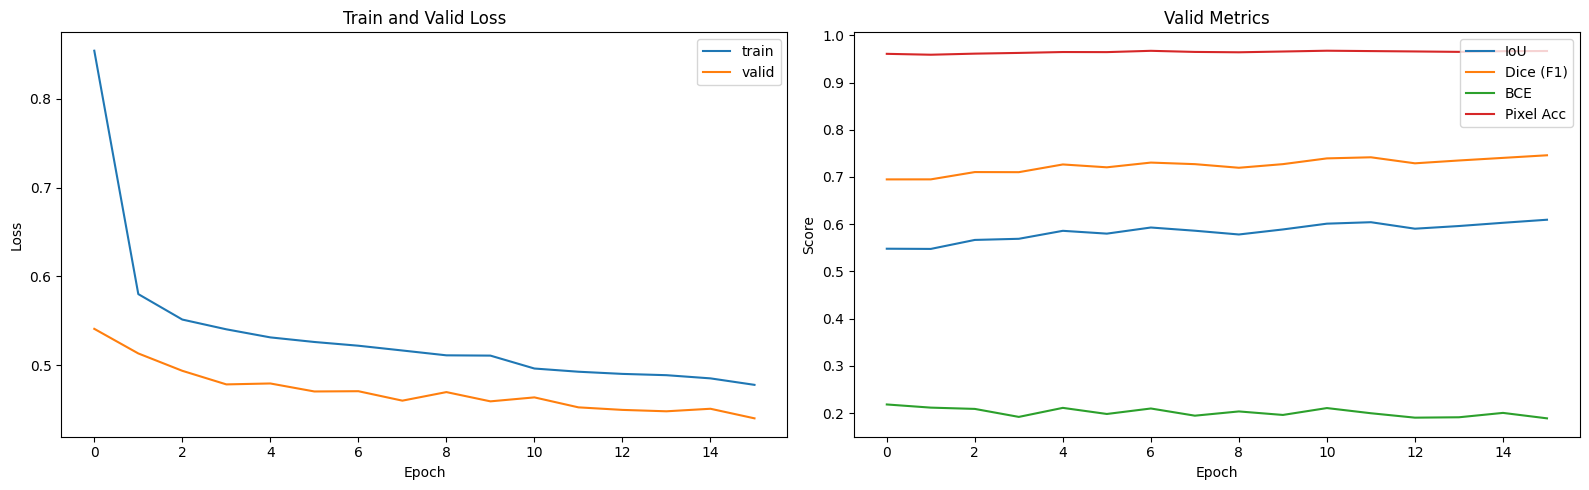

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].set_title('Train and Valid Loss')
ax[0].plot(train_losses, label='train')
ax[0].plot(valid_losses, label='valid')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].set_title('Valid Metrics')
ax[1].plot(iouses, label='IoU')
ax[1].plot(dices, label='Dice (F1)')
ax[1].plot(bceses, label='BCE')
ax[1].plot(accses, label='Pixel Acc')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Score')
ax[1].legend()

plt.tight_layout()

In [7]:
del model, trainloader, validloader

In [10]:
test = r'/home/d.golomolzin/.cache/kagglehub/datasets/balraj98/massachusetts-roads-dataset/versions/1/tiff/'

batch_size = 1
X_test_path  = os.path.join(test, 'test')
y_test_path  = os.path.join(test, 'test_labels')

size_crop = 500
num_show = 2
h, w = 1500, 1500

testloader = DataLoader(
    DataSet(X_test_path, y_test_path, is_test=True),
    batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=False)

Финальные метрики

In [11]:
images = []
num = 0

green = "\033[92m"
reset = "\033[0m"

best_model.eval()
with torch.no_grad():

    iou, dice, bce, acc = .0, .0, .0, .0
    
    for xb, yb in testloader:

        xb, yb = xb.to(device), yb.to(device)
        bs = xb.size(0)

        _, _, h, w = xb.shape

        yb_long = yb.unsqueeze(1)
        yb_float = yb_long.float()

        full_image = torch.zeros((bs, 1, h, w), device=device)

        iou_av, dice_av, bce_av, acc_av = .0, .0, .0, .0
        count = 0

        for i in range(0, h - size_crop + 1, size_crop):
            for j in range(0, w - size_crop + 1, size_crop):

                yb_long_av = yb_long[:, :, i:i+size_crop, j:j+size_crop]
                yb_float_av = yb_float[:, :, i:i+size_crop, j:j+size_crop]

                image_crop = xb[:, :, i:i+size_crop, j:j+size_crop]

                y_pred = best_model(image_crop)
                
                full_image[:, :, i:i+size_crop, j:j+size_crop] = y_pred

                bce_val = bce_func(y_pred, yb_float_av)

                tp, fp, fn, tn = smp.metrics.get_stats(
                    torch.sigmoid(y_pred),
                    yb_long_av,
                    mode='binary',
                    threshold=.5
                )

                iou_val  = smp.metrics.iou_score(tp, fp, fn, tn).mean()
                dice_val = smp.metrics.f1_score(tp, fp, fn, tn).mean()
                acc_val  = smp.metrics.accuracy(tp, fp, fn, tn).mean()

                iou_av += iou_val.item()
                dice_av += dice_val.item()
                acc_av += acc_val.item()
                bce_av += bce_val.item()

                count += 1

        if count > 0:
            iou_av /= count
            dice_av /= count
            acc_av /= count
            bce_av /= count

        images.append((full_image, yb))
        num += 1

        for idx in range(full_image.size(0)):

            pred = (torch.sigmoid(full_image[idx, 0]).cpu().numpy() * 255).astype(np.uint8)
            cv2.imwrite(f'/home/d.golomolzin/AI_labs/2lab/predictions/preds/pred_{num}_{idx}.png', pred)

            mask = (yb[idx].cpu().numpy() * 255).astype(np.uint8)
            cv2.imwrite(f'/home/d.golomolzin/AI_labs/2lab/predictions/masks/mask_{num}_{idx}.png', mask)

        iou += iou_av * bs
        dice += dice_av * bs
        bce += bce_av * bs
        acc += acc_av * bs

    total_test_samples = len(testloader.dataset)
    
    if total_test_samples > 0:
        av_iou = iou / total_test_samples
        av_dice = dice / total_test_samples
        av_bce = bce / total_test_samples
        av_acc = acc / total_test_samples
        
        print(f'Final metrics:')
        print(f'      IoU: {green}{av_iou:.4f}{reset}, Dice: {av_dice:.4f}, Bce: {av_bce:.4f}, Acc: {av_acc:.4f}')

Final metrics:
      IoU: 0.6432, Dice: 0.7645, Bce: 0.1268, Acc: 0.9795


Вывод примеров

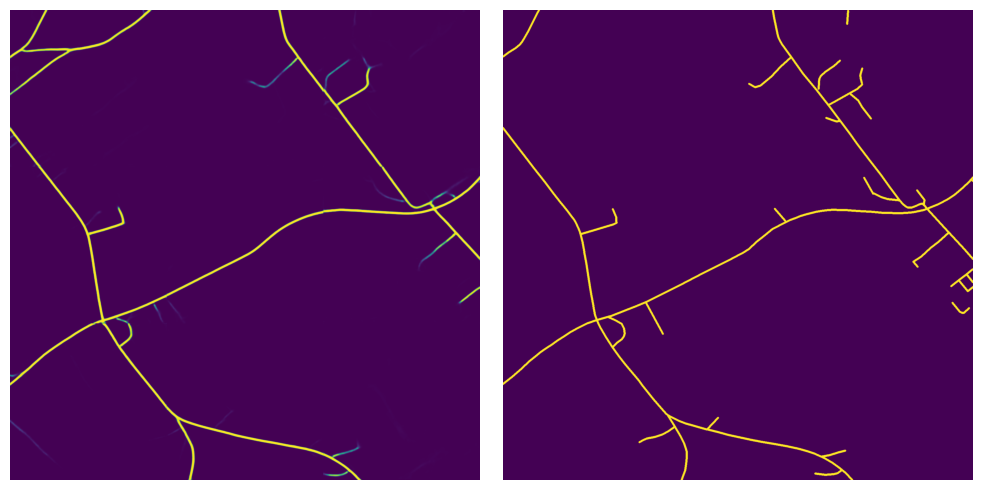

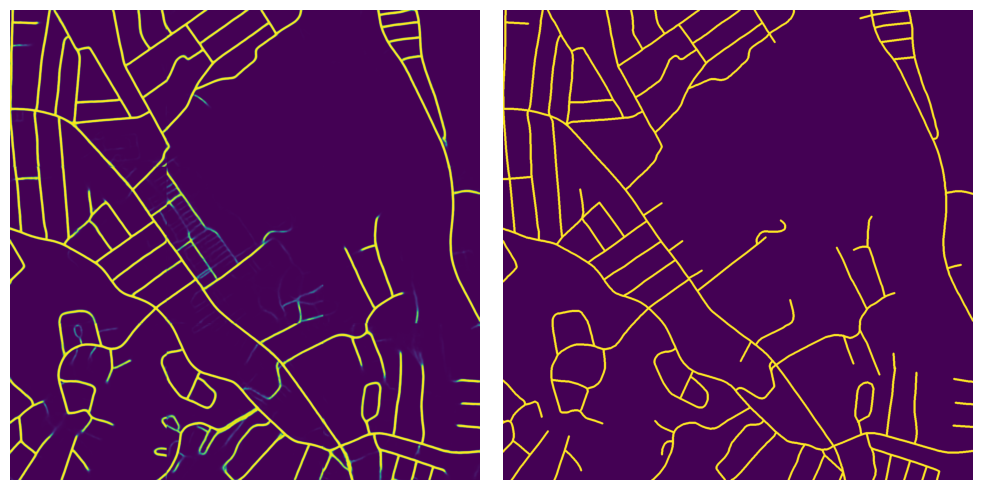

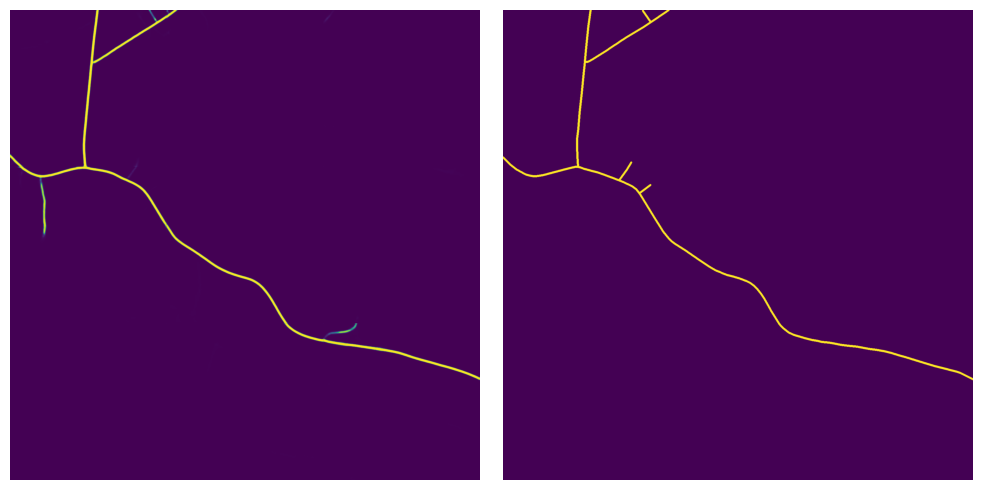

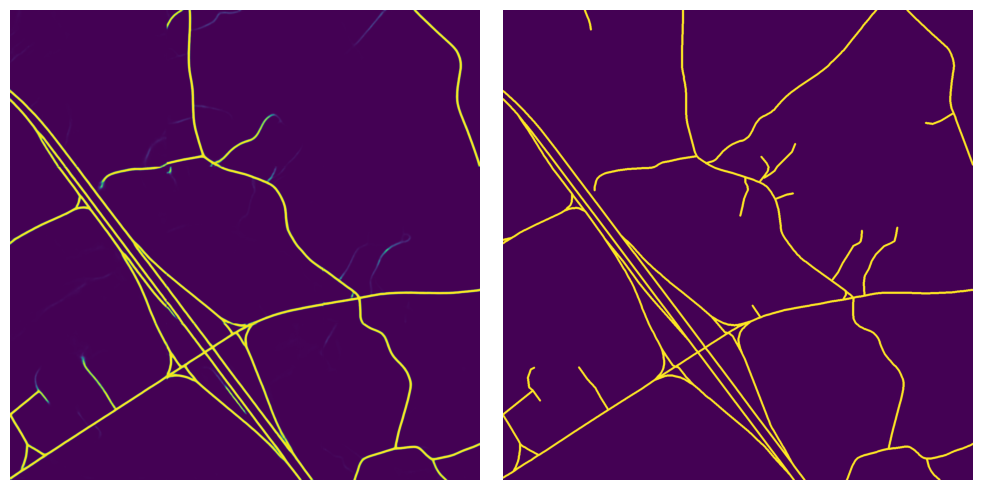

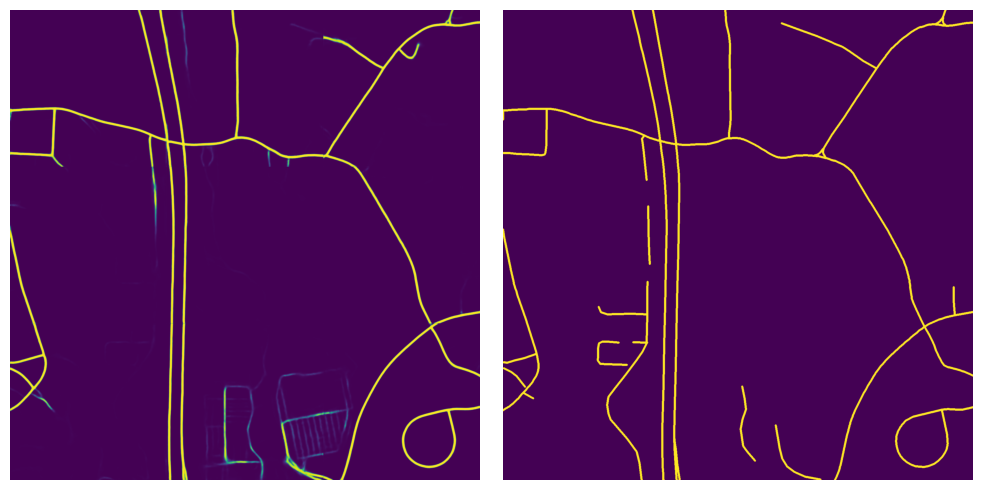

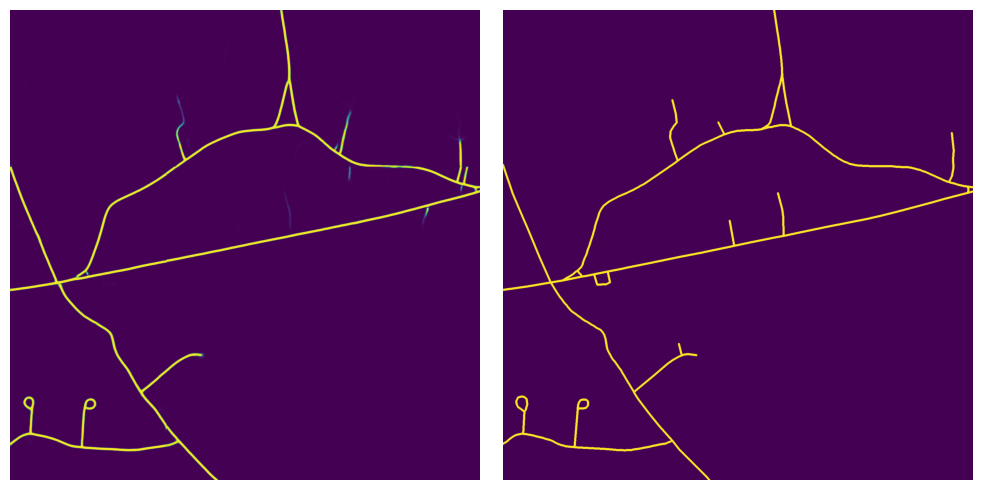

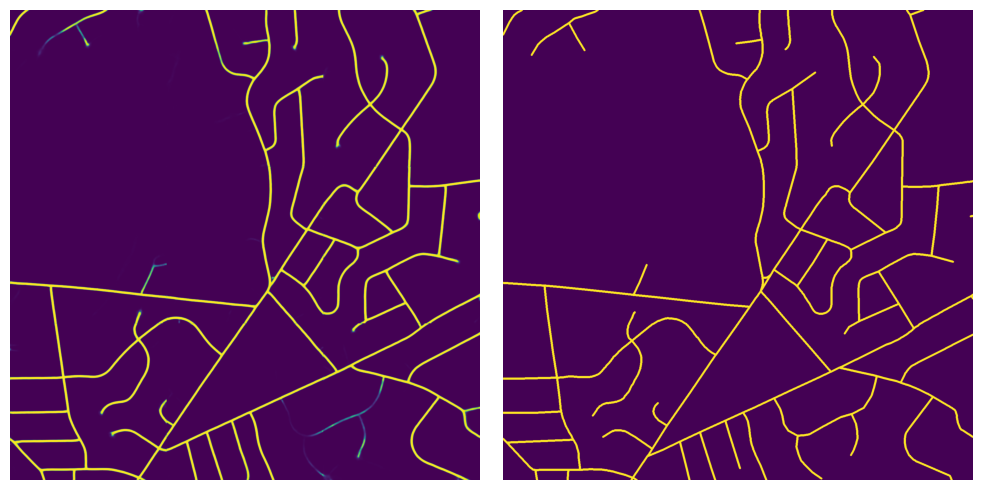

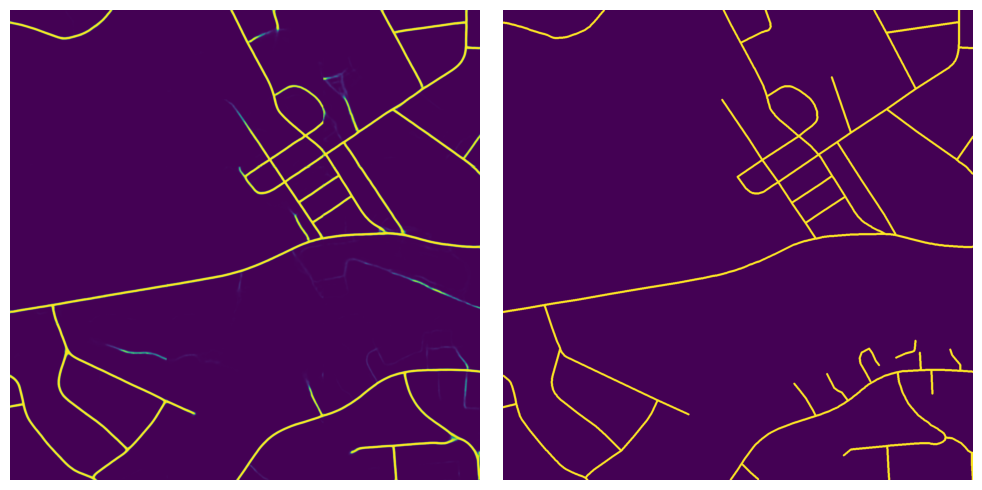

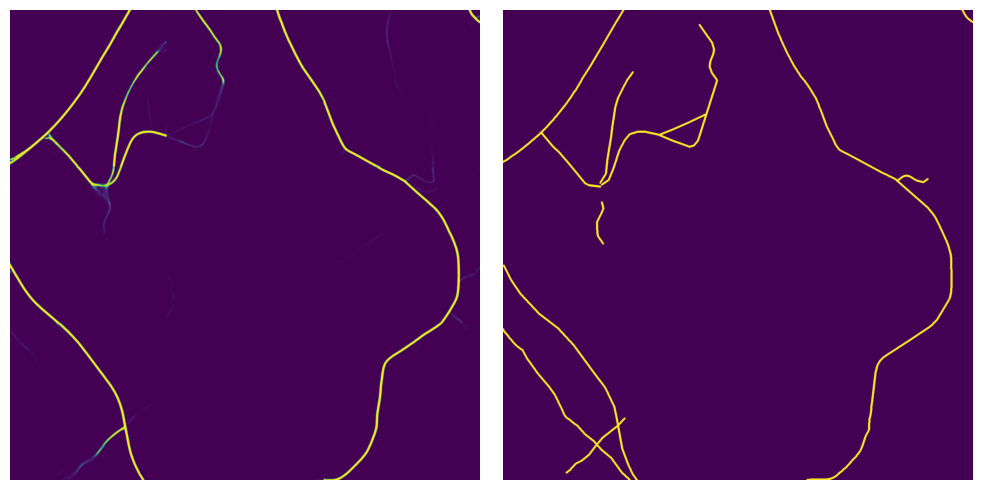

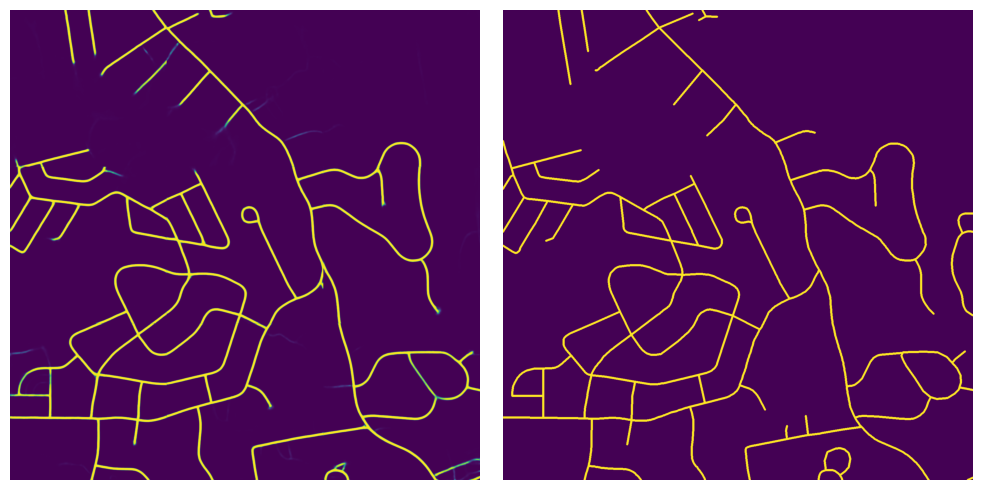

In [13]:
path = r'/home/d.golomolzin/AI_labs/2lab/predictions'
masks_path = os.path.join(path, 'masks')
preds_path = os.path.join(path, 'preds')

num_show = 10
for pred_name,mask_name in zip(sorted(os.listdir(preds_path)), sorted(os.listdir(masks_path))):

    if num_show == 0: break

    fig, ax = plt.subplots(1,2, figsize=(10,5))

    ax[0].imshow(Image.open(os.path.join(preds_path, pred_name)).convert('L'))
    ax[0].axis('off')

    ax[1].imshow(Image.open(os.path.join(masks_path, mask_name)).convert('L'))  
    ax[1].axis('off')

    num_show -= 1
    plt.tight_layout()